** Berlin Public Funding Priorities Analysis (2020–2024)**
Objective:
Understand how public funding priorities evolved across policy areas in Berlin between 2020 and 2024:.

Research Questions:
- Which policy areas received the most funding?
- How did funding priorities change over time?
- What is the balance between project funding and institutional funding?

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving database_berlin_grants.xlsx to database_berlin_grants.xlsx


In [ ]:
df = pd.read_excel("database_berlin_grants.xlsx")
df.head()


,id,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid
0,60658,Forschungsverbund Berlin e. V. \n(FVB),Senatskanzlei - Forschung -,institutionelle Förderung,2020,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,114826400,vr_012174
1,60679,Forschungsverbund Berlin e. V. \n(FVB),"Senatsverwaltung für Wissenschaft, Gesundheit ...",institutionelle Förderung,2024,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,104679900,vr_012174
2,60691,Forschungsverbund Berlin e. V. \n(FVB),"Senatsverwaltung für Wissenschaft, Gesundheit,...",institutionelle Förderung,2023,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,101979700,vr_012174
3,60685,Forschungsverbund Berlin e. V. \n(FVB),"Senatsverwaltung für Wissenschaft, Gesundheit,...",institutionelle Förderung,2022,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,94852300,vr_012174
4,60667,Forschungsverbund Berlin e. V. \n(FVB),Senatskanzlei - Forschung -,institutionelle Förderung,2021,"Rudower Chaussee 17, 12489 Berlin",Forschung,Institutionelle Förderung im Rahmen der Gemein...,91793100,vr_012174


In [ ]:
df.shape

(57469, 10)

In [ ]:
df.columns

Index(['id', 'name', 'geber', 'art', 'jahr', 'anschrift', 'politikbereich',
       'zweck', 'betrag', 'empfaengerid'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57469 entries, 0 to 57468
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              57469 non-null  int64 
 1   name            57469 non-null  object
 2   geber           57469 non-null  object
 3   art             57469 non-null  object
 4   jahr            57469 non-null  int64 
 5   anschrift       57469 non-null  object
 6   politikbereich  57469 non-null  object
 7   zweck           57468 non-null  object
 8   betrag          57469 non-null  int64 
 9   empfaengerid    55987 non-null  object
dtypes: int64(3), object(7)
memory usage: 4.4+ MB


- How many registers are per year?

In [ ]:
df['jahr'].value_counts().sort_index()

,count
jahr,
2020,11281
2021,14011
2022,10615
2023,11753
2024,9809


- How did total public funding envolve between 2020 and 2024?

In [ ]:
df.groupby('jahr')['betrag'].sum().sort_index()

,betrag
jahr,
2020,2870514492
2021,2703000698
2022,2259910184
2023,3123201707
2024,2644024962


- Which policy areas received the highest levels of funding?

In [ ]:
funding_by_policy = (
    df.groupby('politikbereich')['betrag']
    .sum()
    .sort_values(ascending=False)
)
funding_by_policy.head(10)

,betrag
politikbereich,
Wirtschaft,2267632043
Arbeit,1959637273
Forschung,1742715162
Kultur,1107110050
Verkehr,1106371848
Stadtentwicklung,794201351
Jugend,724363859
Wissenschaft,568006796
Gesundheit,537151489


- Funding by policy area and year

In [ ]:
policy_year = (
    df.groupby(['jahr', 'politikbereich'])['betrag']
    .sum()
    .reset_index()
)
policy_year

,jahr,politikbereich,betrag
0,2020,Antidiskriminierung,13642184
1,2020,Arbeit,452273412
2,2020,"Bauen, Wohnen",1268261
3,2020,Berlin-Image,243000
4,2020,Bildung,88646992
...,...,...,...
154,2024,Umwelt,139760333
155,2024,Verbraucherschutz,5465830
156,2024,Verkehr,169696646
157,2024,Wirtschaft,583655906


- Building a pivot table

In [ ]:
policy_pivot = (
    df.pivot_table(
        values = 'betrag',
        index = 'jahr',
        columns = 'politikbereich',
        aggfunc = 'sum'
    )
)
policy_pivot

politikbereich,Antidiskriminierung,Arbeit,"Bauen, Wohnen",Berlin-Image,Bildung,Bürgerschaftliches Engagement,"Bürgerschaftliches Engagement, Bürgerbeteiligung",Denkmalschutz,Europa,Familie,...,Soziales,Sport,Stadtentwicklung,Tierschutz,Umwelt,Verbraucherschutz,Verkehr,Wirtschaft,Wissenschaft,kultur
jahr,,,,,,,,,,,,,,,,,,,,,
2020,13642184.0,452273412.0,1268261.0,243000.0,88646992.0,NaN,4739472.0,2801739.0,615435.0,56414482.0,...,85236014.0,35171107.0,440716084.0,252525.0,70013509.0,5074420.0,311388790.0,315252377.0,125459064.0,NaN
2021,17806921.0,452193244.0,920261.0,858056.0,121972561.0,NaN,5820379.0,2762366.0,977069.0,56665366.0,...,94233709.0,42238519.0,127622318.0,NaN,97954780.0,5758320.0,200232505.0,444463850.0,99467199.0,188124.0
2022,17596288.0,345226411.0,1764762.0,NaN,94236232.0,NaN,6285424.0,3279643.0,1066462.0,65052255.0,...,85883338.0,44651499.0,44919504.0,NaN,100023700.0,5762773.0,210094387.0,262390190.0,94750789.0,27721.0
2023,21316332.0,430284679.0,1426300.0,NaN,119617254.0,103900.0,7587042.0,3389158.0,1660302.0,78050617.0,...,113504310.0,55129079.0,118493965.0,10000.0,102977909.0,6561221.0,214959520.0,661869720.0,125133960.0,108000.0
2024,26228941.0,279659527.0,1303984.0,1335091.0,55195714.0,NaN,12301542.0,10604031.0,1847687.0,51942461.0,...,101265652.0,44412269.0,62449480.0,4000.0,139760333.0,5465830.0,169696646.0,583655906.0,123195784.0,NaN


- Top 10 total funding

In [ ]:
top10 = (
    df.groupby('politikbereich')['betrag']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
top10

Index(['Wirtschaft', 'Arbeit', 'Forschung', 'Kultur', 'Verkehr',
       'Stadtentwicklung', 'Jugend', 'Wissenschaft', 'Gesundheit', 'Umwelt'],
      dtype='object', name='politikbereich')

In [ ]:
policy_pivot_top10 = policy_pivot[top10]

policy_pivot_top10

politikbereich,Wirtschaft,Arbeit,Forschung,Kultur,Verkehr,Stadtentwicklung,Jugend,Wissenschaft,Gesundheit,Umwelt
jahr,,,,,,,,,,
2020,315252377.0,452273412.0,329423781.0,217514524.0,311388790.0,440716084.0,124707590.0,125459064.0,66312614.0,70013509.0
2021,444463850.0,452193244.0,333345619.0,221564807.0,200232505.0,127622318.0,125306388.0,99467199.0,123497977.0,97954780.0
2022,262390190.0,345226411.0,337565353.0,239835386.0,210094387.0,44919504.0,116932610.0,94750789.0,84652848.0,100023700.0
2023,661869720.0,430284679.0,340540756.0,272517065.0,214959520.0,118493965.0,176953685.0,125133960.0,129571351.0,102977909.0
2024,583655906.0,279659527.0,401839653.0,155678268.0,169696646.0,62449480.0,180463586.0,123195784.0,133116699.0,139760333.0


- Total per year policy

In [ ]:
year_totals = policy_pivot.sum(axis=1)
year_totals

,0
jahr,
2020,2.870514e+09
2021,2.703001e+09
2022,2.259910e+09
2023,3.123202e+09
2024,2.644025e+09


- Percentage of total

In [ ]:
policy_share = policy_pivot_top10.div(
   policy_pivot.sum(axis=1),
   axis=0
)*100

policy_share.round(2)

politikbereich,Wirtschaft,Arbeit,Forschung,Kultur,Verkehr,Stadtentwicklung,Jugend,Wissenschaft,Gesundheit,Umwelt
jahr,,,,,,,,,,
2020,10.98,15.76,11.48,7.58,10.85,15.35,4.34,4.37,2.31,2.44
2021,16.44,16.73,12.33,8.20,7.41,4.72,4.64,3.68,4.57,3.62
2022,11.61,15.28,14.94,10.61,9.30,1.99,5.17,4.19,3.75,4.43
2023,21.19,13.78,10.90,8.73,6.88,3.79,5.67,4.01,4.15,3.30
2024,22.07,10.58,15.20,5.89,6.42,2.36,6.83,4.66,5.03,5.29


- Graph policy share

<function matplotlib.pyplot.show(close=None, block=None)>

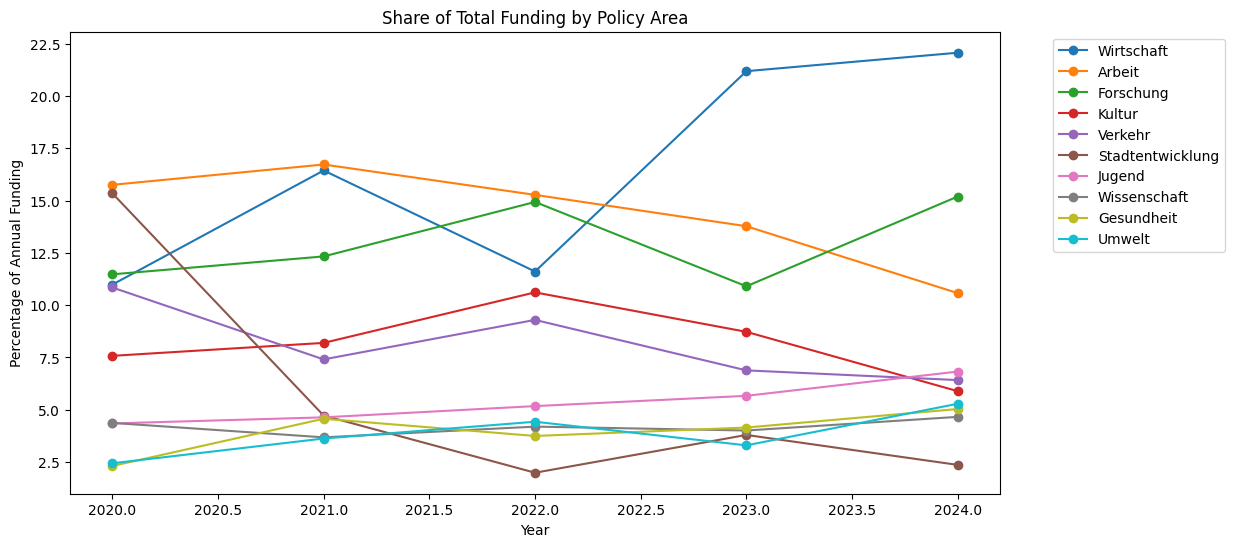

In [ ]:
policy_share.plot(
    figsize=(12,6),
    marker='o'
)
plt.title('Share of Total Funding by Policy Area')
plt.ylabel('Percentage of Annual Funding')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show

In [ ]:
policy_share.round(2)

politikbereich,Wirtschaft,Arbeit,Forschung,Kultur,Verkehr,Stadtentwicklung,Jugend,Wissenschaft,Gesundheit,Umwelt
jahr,,,,,,,,,,
2020,10.98,15.76,11.48,7.58,10.85,15.35,4.34,4.37,2.31,2.44
2021,16.44,16.73,12.33,8.20,7.41,4.72,4.64,3.68,4.57,3.62
2022,11.61,15.28,14.94,10.61,9.30,1.99,5.17,4.19,3.75,4.43
2023,21.19,13.78,10.90,8.73,6.88,3.79,5.67,4.01,4.15,3.30
2024,22.07,10.58,15.20,5.89,6.42,2.36,6.83,4.66,5.03,5.29


- Comparing share change between 2020 and 2024

In [ ]:
change = (
    policy_share.loc[2024] -
    policy_share.loc[2020]
)

change.round(2).sort_values(ascending=False)

,0
politikbereich,
Wirtschaft,11.09
Forschung,3.72
Umwelt,2.85
Gesundheit,2.72
Jugend,2.48
Wissenschaft,0.29
Kultur,-1.69
Verkehr,-4.43
Arbeit,-5.18


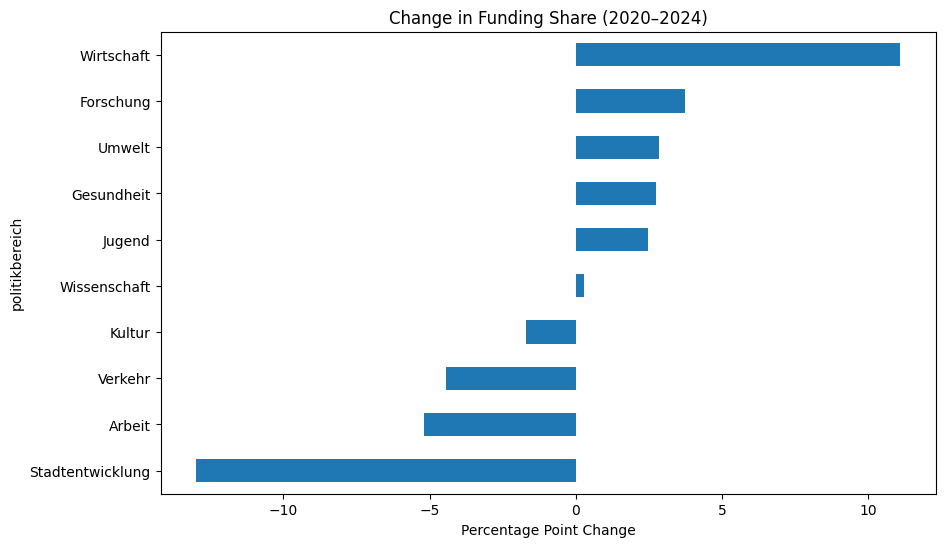

In [ ]:
change.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Change in Funding Share (2020–2024)')
plt.xlabel('Percentage Point Change')
plt.show()

- Funding Evolution Over Time

In [ ]:
annual_funding = (
    df.groupby('jahr')['betrag']
    .sum()
    .reset_index()
)

annual_funding

,jahr,betrag
0,2020,2870514492
1,2021,2703000698
2,2022,2259910184
3,2023,3123201707
4,2024,2644024962


<function matplotlib.pyplot.show(close=None, block=None)>

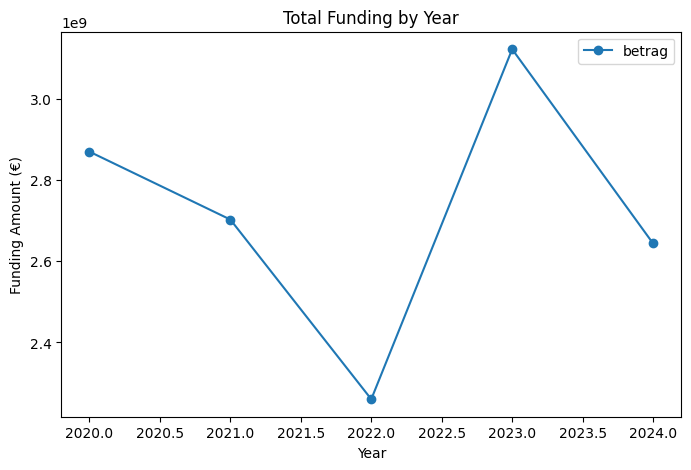

In [ ]:
annual_funding.plot(
    x='jahr',
    y='betrag',
    kind='line',
    marker='o',
    figsize=(8,5)
)

plt.title('Total Funding by Year')
plt.ylabel('Funding Amount (€)')
plt.xlabel('Year')
plt.show

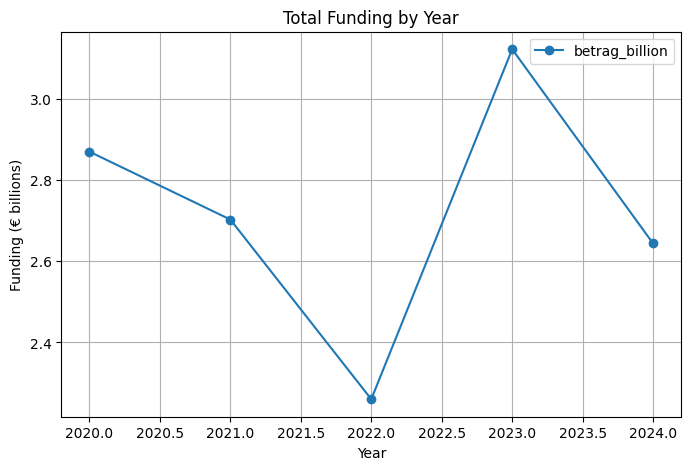

In [ ]:
annual_funding['betrag_billion'] = annual_funding['betrag'] / 1_000_000_000

annual_funding.plot(
    x='jahr',
    y='betrag_billion',
    marker='o',
    figsize=(8,5)
)

plt.title('Total Funding by Year')
plt.ylabel('Funding (€ billions)')
plt.xlabel('Year')
plt.grid(True)
plt.show()

- Funding types

In [ ]:
df['art'].value_counts()

,count
art,
Projektförderung,56096
institutionelle Förderung,1330
Institutionelle Förderung,43


In [ ]:
df['art'] = df['art'].replace(
    'institutionelle Förderung',
    'Institutionelle Förderung'
)

In [ ]:
df['art'].value_counts()

,count
art,
Projektförderung,56096
Institutionelle Förderung,1373


In [ ]:
funding_type = (
    df.groupby(['jahr','art'])['betrag']
    .sum()
    .reset_index()
)

funding_type

,jahr,art,betrag
0,2020,Institutionelle Förderung,574013287
1,2020,Projektförderung,2296501205
2,2021,Institutionelle Förderung,562405025
3,2021,Projektförderung,2140595673
4,2022,Institutionelle Förderung,630297751
5,2022,Projektförderung,1629612433
6,2023,Institutionelle Förderung,622495178
7,2023,Projektförderung,2500706529
8,2024,Institutionelle Förderung,605891758
9,2024,Projektförderung,2038133204


In [ ]:
funding_type_pivot = (
    funding_type.pivot(
        index='jahr',
        columns='art',
        values='betrag'
    )
)

funding_type_pivot

art,Institutionelle Förderung,Projektförderung
jahr,,
2020,574013287,2296501205
2021,562405025,2140595673
2022,630297751,1629612433
2023,622495178,2500706529
2024,605891758,2038133204


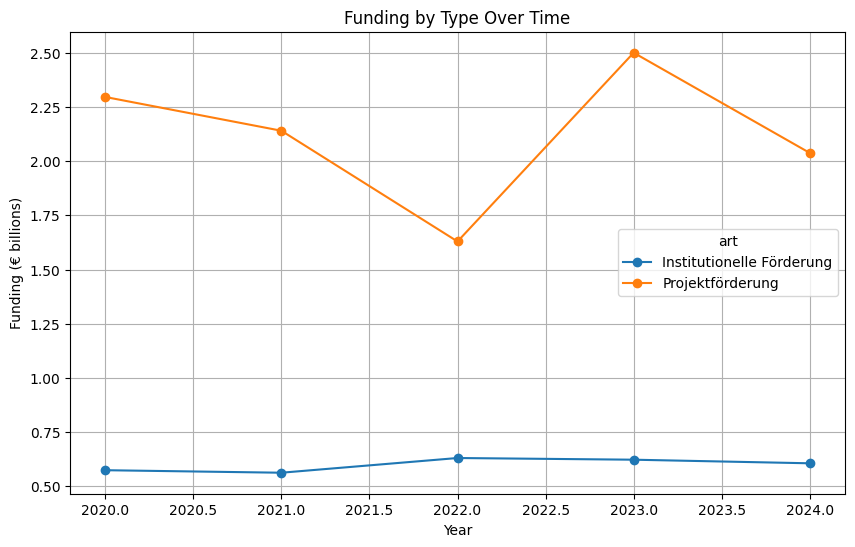

In [ ]:
funding_type_pivot_billion = funding_type_pivot / 1_000_000_000

funding_type_pivot_billion.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.title('Funding by Type Over Time')
plt.ylabel('Funding (€ billions)')
plt.xlabel('Year')
plt.grid(True)
plt.show()

- Which policy areas drove the 2023 funding surge?

In [ ]:
change_23 = (
    policy_pivot.loc[2023] -
    policy_pivot.loc[2022]
).sort_values(ascending=False)

change_23.sort_values(ascending=False).`head()

,0
politikbereich,
Wirtschaft,399479530.0
Arbeit,85058268.0
Stadtentwicklung,73574461.0
Jugend,60021075.0
Gesundheit,44918503.0


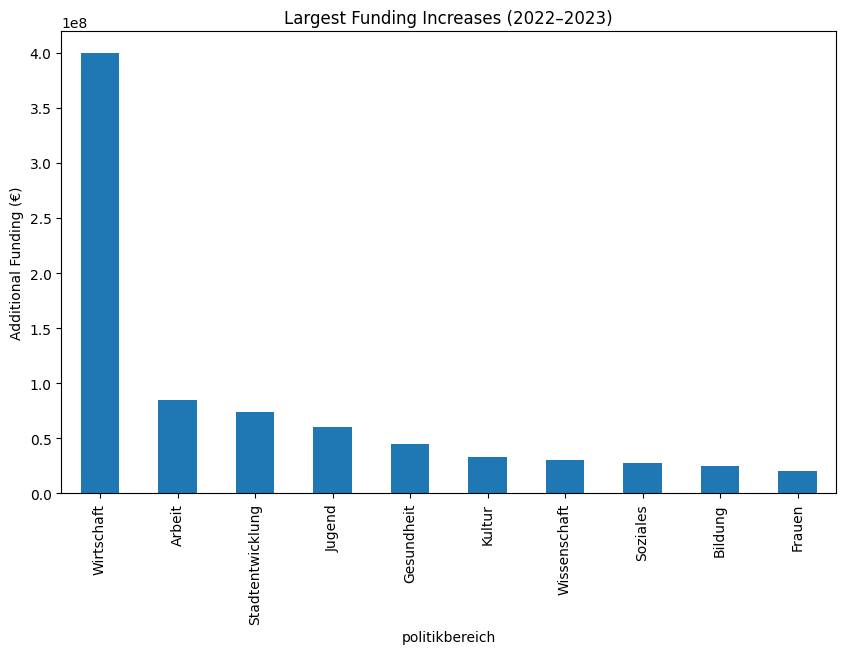

In [ ]:
change_23.head(10).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Largest Funding Increases (2022–2023)')
plt.ylabel('Additional Funding (€)')
plt.show()

- The funding surge observed in 2023 was driven primarily by economic development
initiatives, followed by increases in employment, urban development, youth, and health-related programs.

- Despite their contribution to the 2023 recovery, employment and urban development ended the period with a smaller share of total funding compared to 2020.

- But what is behind 'Wirtschaft'?

In [ ]:
df[
    (df['politikbereich'] == 'Wirtschaft') &
    (df['jahr'] == 2023)
].groupby('zweck')['betrag'] \
 .sum() \
 .sort_values(ascending=False) \
 .head(15)

,betrag
zweck,
Errichtung des Innovationszentrums FUBIC,45000000
Errichtung eines Ausbildungszentrums am Machandelweg,45000000
Effiziente GebäudePLUS,44558979
Erweiterung einer Betriebsstätte,39985970
Errichtung des Gründerzentrums Berlin BioCube auf dem Campus Buch,39305797
Investitionen zur Verbesserung der touristischen Attraktivität des Tierparks Berlin (2.Teilbescheid - Ausbau des Dickhäuterhauses),35655300
Errichtung einer Betriebsstätte,34085610
Investitionen zur Verbesserung der touristischen Attraktivität des Zoologischen Gartens Berlin,20407500
Um- und Ausbau des ABB Aus- und Weiterbildungszentrums Berlin (Haus 14),20155248


In [ ]:
wirtschaft_2023 = df[
    (df['politikbereich'] == 'Wirtschaft') &
    (df['jahr'] == 2023)
]

wirtschaft_2023['betrag'].describe()

,betrag
count,1.694000e+03
mean,3.907141e+05
std,2.541682e+06
min,3.640000e+02
25%,8.000000e+03
50%,1.700000e+04
75%,5.301500e+04
max,4.500000e+07
